In [127]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# searborn vs matplotlib

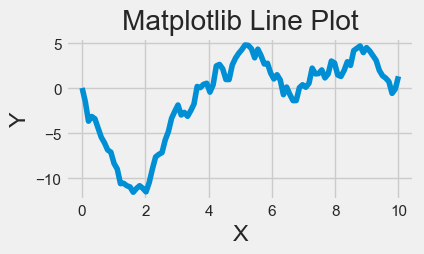

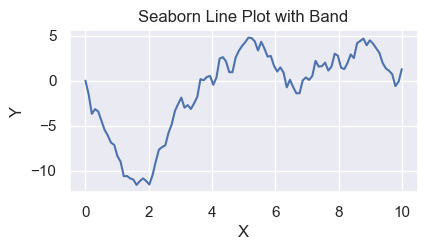

In [128]:
x = np.linspace(0, 10, 100)
y = np.cumsum(np.random.randn(100))

plt.style.use('fivethirtyeight')
plt.figure(figsize=(4, 2))
plt.plot(x, y)
plt.title('Matplotlib Line Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

sns.set_theme()
df = pd.DataFrame({'x': x, 'y': y})
plt.figure(figsize=(4, 2))
sns.lineplot(data=df, x='x', y='y')
plt.title('Seaborn Line Plot with Band')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# exploring searborn plots

# historgrams, kdes, and densities

(array([  2.,  15.,  59., 164., 238., 256., 175.,  65.,  22.,   4.]),
 array([-3.44638138, -2.77092838, -2.09547537, -1.42002236, -0.74456936,
        -0.06911635,  0.60633666,  1.28178966,  1.95724267,  2.63269568,
         3.30814869]),
 <BarContainer object of 10 artists>)

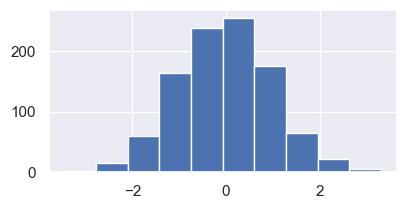

In [129]:
x = np.random.normal(size=1000)
plt.figure(figsize=(4, 2))
plt.hist(x)

<Axes: xlabel='x', ylabel='Density'>

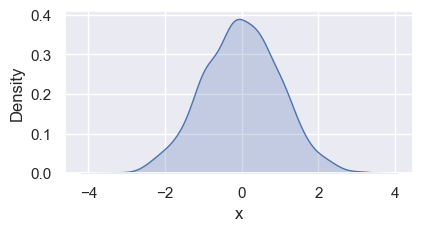

In [130]:
plt.figure(figsize=(4, 2))
data = pd.DataFrame({'x': x})
sns.kdeplot(data=data, x='x', fill=True)

<Figure size 400x200 with 0 Axes>

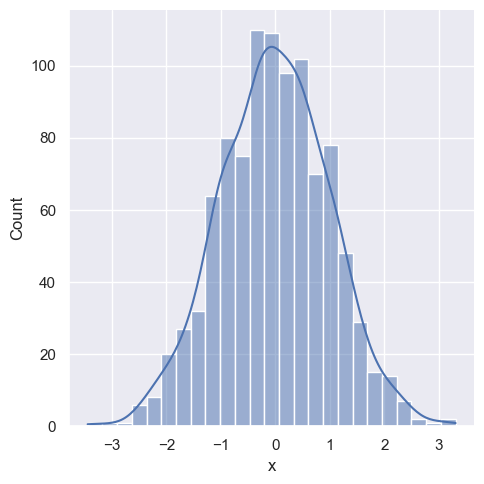

In [131]:
plt.figure(figsize=(4, 2))
sns.displot(data=data, x='x', kde=True)

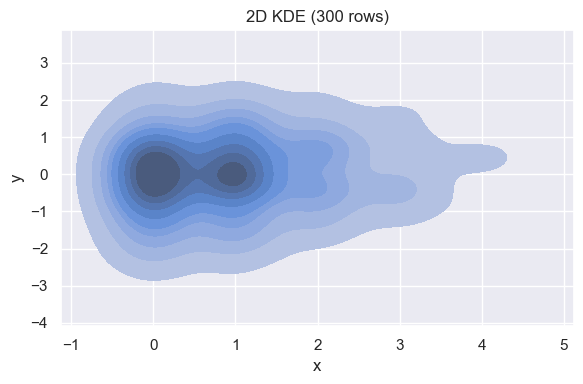

In [132]:
# Recreate to 300 rows so both columns have matching length
data = pd.DataFrame({
    'x': np.random.poisson(lam=1, size=300),
    'y': np.random.normal(size=300)
})
plt.figure(figsize=(6, 4))
sns.kdeplot(data=data, x='x', y='y', fill=True)
plt.title('2D KDE (300 rows)')
plt.tight_layout()
plt.show()

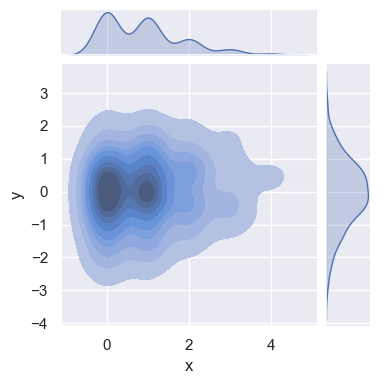

In [133]:
sns.jointplot(data=data, x='x', y='y', kind='kde', fill=True, height=4)

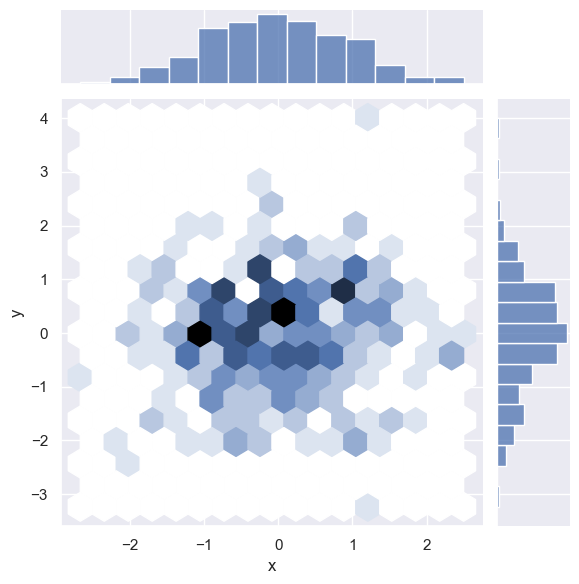

In [135]:
data = pd.DataFrame({
    'x': np.random.normal(size=300),
    'y': np.random.normal(size=300)
})
sns.jointplot(data=data, x='x', y='y', kind='hex')

## pair plots

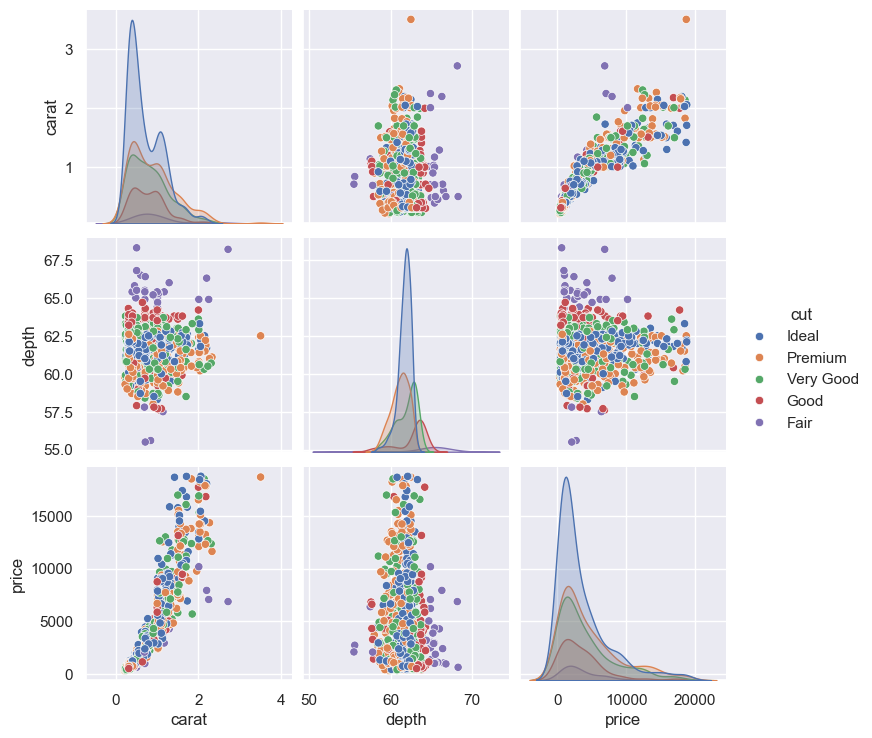

In [183]:
diamonds = sns.load_dataset('diamonds')
diamonds = diamonds.drop(columns=['table', 'x', 'y', 'z'])
indices_to_keep = np.random.choice(diamonds.index, size=1000, replace=False)
diamonds = diamonds.loc[indices_to_keep]
diamonds.reindex()
sns.pairplot(diamonds, hue='cut')

## faceted histograms

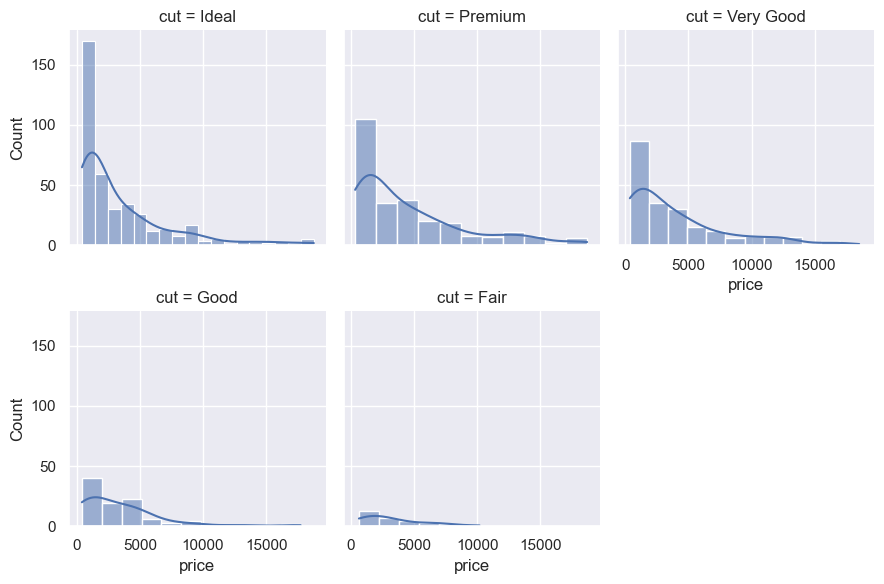

In [184]:
grid = sns.FacetGrid(diamonds, col='cut', col_wrap=3, height=3)
grid.map(sns.histplot, 'price', kde=True)

## factor plots

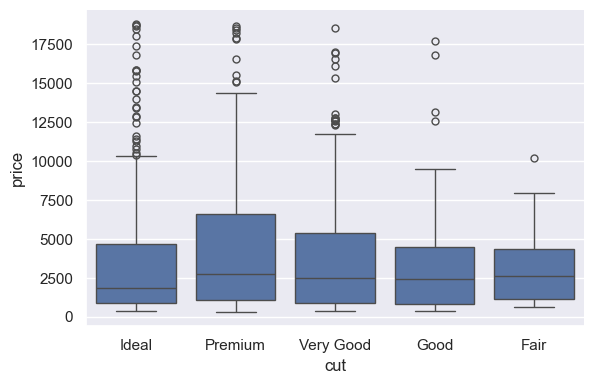

In [185]:
sns.catplot(data=diamonds, x='cut', y='price', kind='box', height=4, aspect=1.5)

## joint distributions

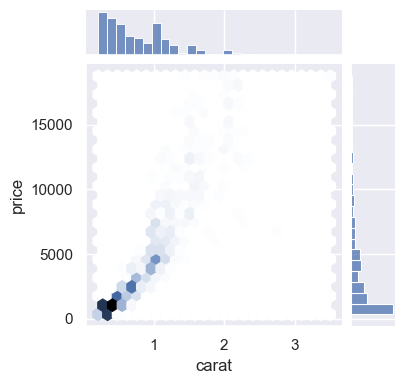

In [186]:
sns.jointplot(data=diamonds, x='carat', y='price', kind='hex', height=4)

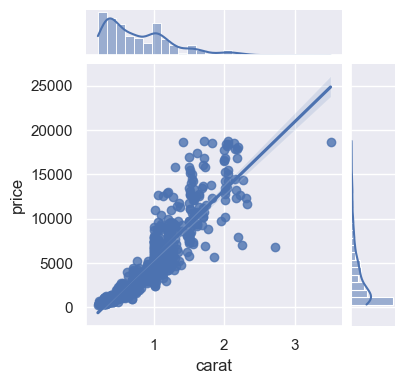

In [187]:
sns.jointplot(data=diamonds, x='carat', y='price', kind='reg', height=4)

## bar plots

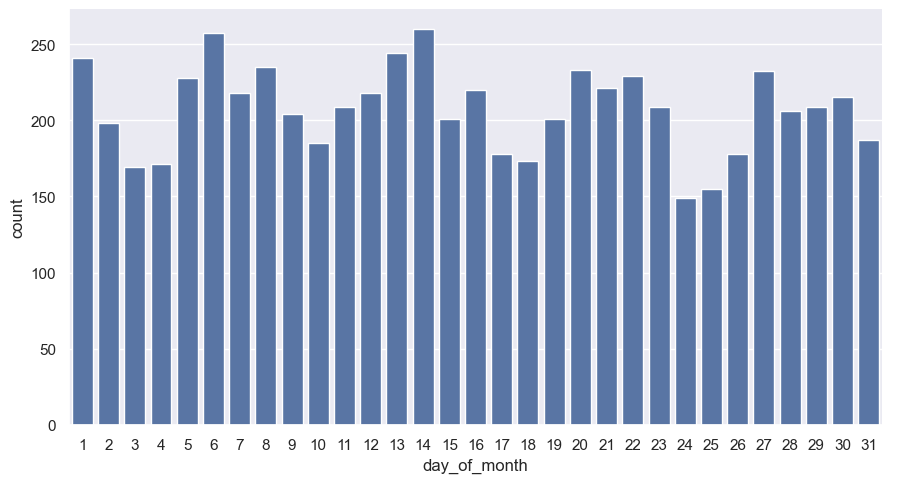

In [200]:
taxis = sns.load_dataset('taxis')
taxis['pickup'] = pd.to_datetime(taxis['pickup'])
taxis['day_of_month'] = taxis['pickup'].dt.day
sns.catplot(data=taxis, x='day_of_month', kind='count', aspect=1.8)